# 04 — Etiquetado y evaluación OOS corregidos

Este notebook incorpora las correcciones derivadas de la auditoría de `03_experimentos_etiquetado.ipynb`:

1. **Cobertura GDELT por fecha**: se comprueba cada día esperado y se descargan los ausentes. Los 404 persistentes se documentan y se excluye cualquier muestra cuya ventana de 60 días los toque; no se interpretan como cero eventos.
2. **Cierre de mercado con DST**: `DATEADDED` se convierte de UTC a `America/New_York` y se aplica el cierre local de las 16:00. Ya no se usa un corte UTC fijo.
3. **Warm-up completo**: se descargan 60 días previos al inicio de etiquetas para no truncar el decay GDELT ni los indicadores de mercado.
4. **Caché versionada por cobertura**: su nombre incluye una firma de los archivos diarios disponibles; si GDELT repone un día, se genera automáticamente una caché distinta.
5. **Sin descarte por “evento en el día”**: una sesión sigue siendo válida aunque ese día no genere aristas; el grafo usa su ventana histórica.
6. **OOS único por fecha**: se promedian probabilidades entre semillas antes de métricas, calibración y backtest. Las 3 semillas no triplican los retornos.
7. **Calibración temporal**: los primeros folds OOS ajustan temperatura + sesgo por clase; los últimos folds quedan como test final intacto.
8. **Umbrales sin mirar el test**: `u_short/u_long` se eligen solo en calibración y se congelan para el test final.
9. **Backtest neto**: incluye costes de transacción y coste anualizado del short, y compone una única trayectoria cronológica.
10. **Baselines correctos**: majority se calcula con el train de cada fold y se reportan macro-F1, balanced accuracy, MCC, NLL, Brier y ECE.

La arquitectura se mantiene fija. El objetivo es medir primero si el etiquetado y la señal aportan valor bajo un protocolo válido.


## 1. Setup y configuración del experimento


In [1]:
import sys
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import config

# Overrides explícitos antes de importar módulos que consumen config.
config.MODO_ETIQUETA = 'asimetrico'
config.UMBRAL_Q_INF = 0.20
config.UMBRAL_Q_SUP = 0.80
config.ENTRENAMIENTO.usar_pesos_clase = True

FECHA_MODELO_INI = date.fromisoformat(config.FECHA_INICIO)
FECHA_FIN = date.fromisoformat(config.FECHA_FIN)
FECHA_DATOS_INI = FECHA_MODELO_INI - timedelta(days=config.VENTANA_DECAY_DIAS)

print('ROOT:', ROOT)
print('Dispositivo:', 'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Periodo etiquetas: {FECHA_MODELO_INI} a {FECHA_FIN}')
print(f'Periodo datos con warm-up: {FECHA_DATOS_INI} a {FECHA_FIN}')
print(f'Cierre: {config.HORA_CIERRE_MERCADO_LOCAL}:00 {config.ZONA_HORARIA_MERCADO}')
print(f'Etiqueta: {config.MODO_ETIQUETA} q{config.UMBRAL_Q_INF:.2f}/q{config.UMBRAL_Q_SUP:.2f}')
print(f'Pesos de clase: {config.ENTRENAMIENTO.usar_pesos_clase}')
print(f'Costes: {config.COSTE_TRANSACCION_BPS:.1f} bps/rotación; short {config.COSTE_SHORT_ANUAL_BPS:.1f} bps/año')


ROOT: c:\Users\Ricard.Martin\Desktop\Repositorios_Kai\ai-gnn-gdelt-sp500
Dispositivo: cuda
Periodo etiquetas: 2015-01-01 a 2025-12-31
Periodo datos con warm-up: 2014-11-02 a 2025-12-31
Cierre: 16:00 America/New_York
Etiqueta: asimetrico q0.20/q0.80
Pesos de clase: True
Costes: 5.0 bps/rotación; short 100.0 bps/año


## 2. Auditoría y descarga GDELT


In [2]:
from src.datos.descarga_gdelt import auditar_cobertura_local, descargar_rango

cobertura_antes = auditar_cobertura_local(FECHA_DATOS_INI, FECHA_FIN)
print('Cobertura antes:', cobertura_antes.resumen())
if not cobertura_antes.completa:
    muestra = [d.isoformat() for d in (*cobertura_antes.faltantes, *cobertura_antes.vacios)[:20]]
    print('Fechas que se intentarán recuperar:', muestra)

# Recorre el rango completo, pero descargar_dia omite inmediatamente lo ya presente.
# Un 404 de GDELT se registra como día no disponible y no bloquea el estudio.
rutas_gdelt = descargar_rango(
    FECHA_DATOS_INI,
    FECHA_FIN,
    exigir_completo=False,
)
cobertura = auditar_cobertura_local(FECHA_DATOS_INI, FECHA_FIN)
print('Cobertura final:', cobertura.resumen())
fechas_gdelt_no_disponibles = tuple(sorted({
    *cobertura.faltantes,
    *cobertura.vacios,
}))
if fechas_gdelt_no_disponibles:
    print('AVISO: se excluirán las ventanas afectadas por estas fechas:')
    print([d.isoformat() for d in fechas_gdelt_no_disponibles])
assert rutas_gdelt, 'No hay archivos GDELT utilizables'


Cobertura antes: 4058/4078 días válidos | faltantes=20 | vacíos=0
Fechas que se intentarán recuperar: ['2022-11-10', '2023-03-23', '2025-06-14', '2025-06-15', '2025-06-16', '2025-06-17', '2025-06-18', '2025-06-19', '2025-06-20', '2025-06-21', '2025-06-22', '2025-06-23', '2025-06-24', '2025-06-25', '2025-06-26', '2025-06-27', '2025-06-28', '2025-06-29', '2025-06-30', '2025-07-01']
18:57:28 [INFO] src.datos.descarga_gdelt: Descargando GDELT desde 2014-11-02 hasta 2025-12-31 (4078 días)
18:57:28 [WARNING] src.datos.descarga_gdelt: No existe en el servidor: http://data.gdeltproject.org/events/20221110.export.CSV.zip
18:57:28 [WARNING] src.datos.descarga_gdelt: No existe en el servidor: http://data.gdeltproject.org/events/20230323.export.CSV.zip
18:57:28 [WARNING] src.datos.descarga_gdelt: No existe en el servidor: http://data.gdeltproject.org/events/20250614.export.CSV.zip
18:57:28 [WARNING] src.datos.descarga_gdelt: No existe en el servidor: http://data.gdeltproject.org/events/20250615.ex

## 3. Datos financieros con warm-up


In [3]:
from src.datos.descarga_financiero import descargar_sp500, descargar_vix

precios = descargar_sp500(FECHA_DATOS_INI, FECHA_FIN)
vix = descargar_vix(FECHA_DATOS_INI, FECHA_FIN)
macro = None

print(f'SP500: {len(precios)} sesiones | {precios.index.min().date()} a {precios.index.max().date()}')
print(f'VIX:   {len(vix)} puntos')


18:57:31 [INFO] src.datos.descarga_financiero: Descargando S&P 500 desde 2014-11-02 hasta 2025-12-31
18:57:33 [INFO] src.datos.descarga_financiero: Guardado en caché: sp500_20141102_20251231.csv
18:57:33 [INFO] src.datos.descarga_financiero: Descargando VIX desde 2014-11-02 hasta 2025-12-31
SP500: 2806 sesiones | 2014-11-03 a 2025-12-30
VIX:   2806 puntos


## 4. Preproceso GDELT con caché versionada


In [4]:
import hashlib

from src.datos.preprocesar import preprocesar_y_agregar_por_tramos, cargar_agregados_de_disco

# La firma evita reutilizar agregados si cambia cualquier fichero disponible.
material_firma = '|'.join(f'{p.name}:{p.stat().st_size}' for p in rutas_gdelt)
firma_cobertura = hashlib.sha256(material_firma.encode('utf-8')).hexdigest()[:12]
DIR_AGREGADOS = ROOT / 'data' / f'agregados_nb04_dst_v2_{firma_cobertura}'
print('Caché de agregados:', DIR_AGREGADOS)
preprocesar_y_agregar_por_tramos(
    rutas_gdelt,
    DIR_AGREGADOS,
    dias_por_tramo=180,
)
df_agregado, df_participacion = cargar_agregados_de_disco(DIR_AGREGADOS)

assert not df_agregado.empty
assert not df_participacion.empty
assert not df_agregado.duplicated(['fecha', 'pais_origen', 'pais_destino', 'quadclass']).any()
assert not df_participacion.duplicated(['fecha', 'pais', 'rol', 'quadclass']).any()
print(f'Aristas: {len(df_agregado):,} | días={df_agregado.fecha.nunique():,}')
print(f'Participación: {len(df_participacion):,} | días={df_participacion.fecha.nunique():,}')


Caché de agregados: c:\Users\Ricard.Martin\Desktop\Repositorios_Kai\ai-gnn-gdelt-sp500\data\agregados_nb04_dst_v2_14267dbfda29
18:57:34 [INFO] src.datos.preprocesar: Procesando 4058 ficheros en 23 tramos de 180 días
18:59:15 [INFO] src.datos.preprocesar: Preprocesado total: 6760799 eventos en 180 días
18:59:17 [INFO] src.datos.preprocesar: Tramo 1/23: 103765 aristas, 28767 participaciones -> guardado
19:01:10 [INFO] src.datos.preprocesar: Preprocesado total: 7749642 eventos en 180 días
19:01:12 [INFO] src.datos.preprocesar: Tramo 2/23: 111709 aristas, 28775 participaciones -> guardado
19:03:17 [INFO] src.datos.preprocesar: Preprocesado total: 8383961 eventos en 180 días
19:03:20 [INFO] src.datos.preprocesar: Tramo 3/23: 116902 aristas, 28791 participaciones -> guardado
19:05:27 [INFO] src.datos.preprocesar: Preprocesado total: 8472988 eventos en 180 días
19:05:30 [INFO] src.datos.preprocesar: Tramo 4/23: 114958 aristas, 28783 participaciones -> guardado
19:07:35 [INFO] src.datos.prepro

## 5. Etiquetas, folds y auditoría de regímenes


In [5]:
from src.datos.etiquetas import (
    clases_para_fold,
    construir_etiquetas_diarias,
    mascara_historial_gdelt_completo,
)
from src.entrenamiento.walkforward import construir_folds

etiquetas_todas = construir_etiquetas_diarias(precios)
etiquetas_periodo = etiquetas_todas[
    (pd.to_datetime(etiquetas_todas['fecha_target']).dt.date >= FECHA_MODELO_INI)
    & (pd.to_datetime(etiquetas_todas['fecha_target']).dt.date <= FECHA_FIN)
].reset_index(drop=True)

historial_completo = mascara_historial_gdelt_completo(
    etiquetas_periodo['fecha_grafo'],
    fechas_gdelt_no_disponibles,
    ventana_dias=config.VENTANA_DECAY_DIAS,
)
etiquetas_excluidas = etiquetas_periodo.loc[~historial_completo, [
    'fecha_grafo', 'fecha_target', 'retorno',
]]
etiquetas = etiquetas_periodo.loc[historial_completo].reset_index(drop=True)

# No se exige una arista fechada exactamente en fecha_grafo: un día sin
# evento sigue teniendo un grafo válido construido con los 60 días previos.
print(
    f'Excluidas por historial GDELT incompleto: {len(etiquetas_excluidas):,} '
    f'de {len(etiquetas_periodo):,}'
)
if not etiquetas_excluidas.empty:
    display(etiquetas_excluidas.groupby(
        pd.to_datetime(etiquetas_excluidas['fecha_grafo']).dt.year
    ).size().rename('muestras_excluidas').to_frame())

retornos_por_indice = etiquetas['retorno'].to_numpy(dtype=float)
folds = construir_folds(fechas=etiquetas['fecha_grafo'])

auditoria_folds = []
for fold in folds:
    clases_fold, umbrales = clases_para_fold(retornos_por_indice, fold.idx_train)
    dist = np.bincount(clases_fold[fold.idx_val], minlength=3)
    auditoria_folds.append({
        'fold': fold.fold_id,
        'train_n': len(fold.idx_train),
        'test_n': len(fold.idx_val),
        'test_inicio': fold.fecha_val_inicio.date(),
        'test_fin': fold.fecha_val_fin.date(),
        'q_inf': umbrales.q_inf,
        'q_sup': umbrales.q_sup,
        'baja_%': 100 * dist[0] / dist.sum(),
        'neutro_%': 100 * dist[1] / dist.sum(),
        'sube_%': 100 * dist[2] / dist.sum(),
    })

auditoria_folds = pd.DataFrame(auditoria_folds)
print(f'Etiquetas: {len(etiquetas):,} | folds={len(folds)}')
display(auditoria_folds.round(3))


19:32:44 [INFO] src.datos.etiquetas: Discretización PROVISIONAL (serie completa): modo=asimetrico | q_inf=-0.00557 | q_sup=+0.00737
19:32:44 [INFO] src.datos.etiquetas: Etiquetas construidas: 2805 sesiones
19:32:44 [INFO] src.datos.etiquetas: Distribución de clases (PROVISIONAL, se recalcula por fold):
clase
0     561
1    1683
2     561
Name: count, dtype: int64
Excluidas por historial GDELT incompleto: 135 de 2,765


,muestras_excluidas
fecha_grafo,
2022,35
2023,47
2025,53


19:32:44 [INFO] src.entrenamiento.walkforward: Walk-forward: 10 folds, modo=expansiva, train inicial=239 muestras, val=239 muestras, embargo=0, N=2630, rango=2014-12-31 a 2025-12-29
19:32:44 [INFO] src.entrenamiento.walkforward:   Fold 0: train [2014-12-31, 2015-12-10] n=239 | val [2015-12-11, 2016-11-21] n=239
19:32:44 [INFO] src.entrenamiento.walkforward:   Fold 1: train [2014-12-31, 2016-11-21] n=478 | val [2016-11-22, 2017-11-02] n=239
19:32:44 [INFO] src.entrenamiento.walkforward:   Fold 2: train [2014-12-31, 2017-11-02] n=717 | val [2017-11-03, 2018-10-16] n=239
19:32:44 [INFO] src.entrenamiento.walkforward:   Fold 3: train [2014-12-31, 2018-10-16] n=956 | val [2018-10-17, 2019-09-30] n=239
19:32:44 [INFO] src.entrenamiento.walkforward:   Fold 4: train [2014-12-31, 2019-09-30] n=1195 | val [2019-10-01, 2020-09-10] n=239
19:32:44 [INFO] src.entrenamiento.walkforward:   Fold 5: train [2014-12-31, 2020-09-10] n=1434 | val [2020-09-11, 2021-08-23] n=239
19:32:44 [INFO] src.entrenamie

,fold,train_n,test_n,test_inicio,test_fin,q_inf,q_sup,baja_%,neutro_%,sube_%
0,0,239,239,2015-12-11,2016-11-21,-0.006,0.007,17.155,66.109,16.736
1,1,478,239,2016-11-22,2017-11-02,-0.006,0.006,5.858,84.937,9.205
2,2,717,239,2017-11-03,2018-10-16,-0.004,0.005,21.757,54.393,23.849
3,3,956,239,2018-10-17,2019-09-30,-0.004,0.005,25.523,46.444,28.033
4,4,1195,239,2019-10-01,2020-09-10,-0.004,0.006,25.105,41.004,33.891
5,5,1434,239,2020-09-11,2021-08-23,-0.005,0.007,21.339,52.301,26.360
6,6,1673,239,2021-08-24,2022-08-04,-0.005,0.007,32.218,40.167,27.615
7,7,1912,239,2022-08-05,2023-11-13,-0.005,0.007,30.544,45.188,24.268
8,8,2151,239,2023-11-14,2024-10-25,-0.006,0.008,14.644,66.109,19.247
9,9,2390,239,2024-10-28,2025-12-26,-0.006,0.008,18.828,64.854,16.318


## 6. Dataset y entrenamiento


In [6]:
from src.datos.dataset import DatasetGrafoDiario

dataset = DatasetGrafoDiario(
    eventos_agregados=df_agregado,
    etiquetas=etiquetas,
    precios_sp500=precios,
    macro=macro,
    vix=vix,
    participacion=df_participacion,
    precomputar=True,
)
print(f'Dataset: {len(dataset):,} grafos')


19:32:47 [INFO] src.datos.dataset: Precomputando 2630 grafos...
19:35:49 [INFO] src.datos.dataset: Precomputación completada
Dataset: 2,630 grafos


In [7]:
from src.entrenamiento.loop import entrenar_walkforward

dispositivo = 'cuda' if torch.cuda.is_available() else 'cpu'
resultado = entrenar_walkforward(
    dataset=dataset,
    folds=folds,
    semillas=config.ENTRENAMIENTO.semillas,
    dispositivo=dispositivo,
    retornos_por_indice=retornos_por_indice,
)
print(resultado.resumen_final())


19:35:49 [INFO] src.entrenamiento.loop: ======================================================================
19:35:49 [INFO] src.entrenamiento.loop: FOLD 0  (train n=239, test n=239)
19:35:49 [INFO] src.entrenamiento.loop: ======================================================================
19:35:49 [INFO] src.entrenamiento.loop: --- Semilla 0 ---
19:35:49 [INFO] src.datos.etiquetas: Etiquetas por fold: modo=asimetrico | q_inf=-0.00621 | q_sup=+0.00709
19:35:49 [INFO] src.datos.etiquetas: Distribución en train del fold (baja/neutro/sube): [48, 143, 48]
19:35:49 [INFO] src.datos.normalizacion: Normalizador ajustado sobre 203 grafos de train (country 11 cols, market 9 cols, edge_cc 3 cols continuas)
19:35:54 [INFO] src.entrenamiento.loop:   Clasificación: acc=0.6067 | F1_macro=0.4219 | F1_clases=[0.184, 0.763, 0.319] | n=239
19:35:54 [INFO] src.entrenamiento.loop:   Financiero:    rent_estr=+9.21% | rent_BH=+9.47% | vs_BH=-0.26pp | sharpe=0.94 | maxDD=-10.62% | long/short/cash=134/0/

## 7. Ensemble OOS único y baselines por fold


In [8]:
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    matthews_corrcoef,
    precision_recall_fscore_support,
)

oos = resultado.tabla_oos(promediar_semillas=True)
n_oos_esperado = sum(len(f.idx_val) for f in folds)
assert len(oos) == n_oos_esperado
assert oos['indice'].is_unique

columnas_p = ['p_baja', 'p_neutro', 'p_sube']
probas_raw = oos[columnas_p].to_numpy()
y_true = oos['y_true'].to_numpy(dtype=int)
y_pred_raw = probas_raw.argmax(axis=1)

# Majority usa exclusivamente las etiquetas del train de cada fold.
preds_majority = []
reales_fold = []
for fold in folds:
    clases_fold, _ = clases_para_fold(retornos_por_indice, fold.idx_train)
    mayoria = int(np.bincount(clases_fold[fold.idx_train], minlength=3).argmax())
    preds_majority.append(np.full(len(fold.idx_val), mayoria, dtype=int))
    reales_fold.append(clases_fold[fold.idx_val])
preds_majority = np.concatenate(preds_majority)
reales_fold = np.concatenate(reales_fold)
np.testing.assert_array_equal(y_true, reales_fold)

def resumen_clasificacion(nombre, reales, predichas):
    return {
        'modelo': nombre,
        'accuracy': accuracy_score(reales, predichas),
        'balanced_accuracy': balanced_accuracy_score(reales, predichas),
        'f1_macro': f1_score(reales, predichas, average='macro', zero_division=0),
        'mcc': matthews_corrcoef(reales, predichas),
    }

tabla_clasificacion = pd.DataFrame([
    resumen_clasificacion('majority por fold', y_true, preds_majority),
    resumen_clasificacion('HGNN ensemble raw', y_true, y_pred_raw),
])
display(tabla_clasificacion.round(4))

prec, rec, f1c, soporte = precision_recall_fscore_support(
    y_true, y_pred_raw, labels=[0, 1, 2], zero_division=0,
)
display(pd.DataFrame({
    'clase': ['baja', 'neutro', 'sube'],
    'precision': prec,
    'recall': rec,
    'f1': f1c,
    'soporte': soporte,
}).round(4))
print(f'OOS únicas: {len(oos):,}; ejecuciones fold-semilla: {len(resultado.registros_oos)}')


19:40:35 [INFO] src.datos.etiquetas: Etiquetas por fold: modo=asimetrico | q_inf=-0.00621 | q_sup=+0.00709
19:40:35 [INFO] src.datos.etiquetas: Distribución en train del fold (baja/neutro/sube): [48, 143, 48]
19:40:35 [INFO] src.datos.etiquetas: Etiquetas por fold: modo=asimetrico | q_inf=-0.00571 | q_sup=+0.00640
19:40:35 [INFO] src.datos.etiquetas: Distribución en train del fold (baja/neutro/sube): [96, 286, 96]
19:40:35 [INFO] src.datos.etiquetas: Etiquetas por fold: modo=asimetrico | q_inf=-0.00376 | q_sup=+0.00522
19:40:35 [INFO] src.datos.etiquetas: Distribución en train del fold (baja/neutro/sube): [144, 429, 144]
19:40:35 [INFO] src.datos.etiquetas: Etiquetas por fold: modo=asimetrico | q_inf=-0.00386 | q_sup=+0.00537
19:40:35 [INFO] src.datos.etiquetas: Distribución en train del fold (baja/neutro/sube): [191, 574, 191]
19:40:35 [INFO] src.datos.etiquetas: Etiquetas por fold: modo=asimetrico | q_inf=-0.00427 | q_sup=+0.00608
19:40:35 [INFO] src.datos.etiquetas: Distribución en 

,modelo,accuracy,balanced_accuracy,f1_macro,mcc
0,majority por fold,0.5615,0.3333,0.2397,0.0000
1,HGNN ensemble raw,0.5222,0.4454,0.4381,0.2085


,clase,precision,recall,f1,soporte
0,baja,0.2683,0.2161,0.2394,509
1,neutro,0.7202,0.6654,0.6917,1342
2,sube,0.3311,0.4545,0.3831,539


OOS únicas: 2,390; ejecuciones fold-semilla: 30


## 8. Calibración temporal: temperatura + sesgo por clase

Los primeros cinco folds OOS forman el bloque de calibración. Los cinco últimos son el test final y no participan ni en el ajuste del calibrador ni en la elección de umbrales financieros. El sesgo por clase permite corregir el cambio de prior inducido por la loss ponderada; una temperatura escalar por sí sola no puede hacerlo.


In [9]:
import torch.nn.functional as F

fold_ids = sorted(oos['fold_id'].unique())
punto_corte = max(1, len(fold_ids) // 2)
folds_cal = fold_ids[:punto_corte]
folds_test = fold_ids[punto_corte:]
mask_cal = oos['fold_id'].isin(folds_cal).to_numpy()
mask_test = oos['fold_id'].isin(folds_test).to_numpy()
assert mask_cal.any() and mask_test.any()

logits_np = np.log(np.clip(probas_raw, 1e-8, 1.0))
logits_cal = torch.tensor(logits_np[mask_cal], dtype=torch.float32)
y_cal = torch.tensor(y_true[mask_cal], dtype=torch.long)

log_T = torch.nn.Parameter(torch.tensor(0.0))
bias = torch.nn.Parameter(torch.zeros(3))
optimizador_cal = torch.optim.LBFGS([log_T, bias], lr=0.1, max_iter=150)

def transformar_logits(logits):
    bias_centrado = bias - bias.mean()
    return logits / log_T.exp().clamp(min=1e-3, max=100.0) + bias_centrado

def closure_cal():
    optimizador_cal.zero_grad()
    loss = F.cross_entropy(transformar_logits(logits_cal), y_cal)
    loss = loss + 1e-4 * (bias - bias.mean()).square().sum()
    loss.backward()
    return loss

optimizador_cal.step(closure_cal)
T_opt = float(log_T.exp().item())
bias_opt = (bias - bias.mean()).detach().numpy()

with torch.no_grad():
    logits_todos = torch.tensor(logits_np, dtype=torch.float32)
    probas_calibradas = F.softmax(transformar_logits(logits_todos), dim=-1).numpy()

def metricas_probabilisticas(probas_eval, y_eval):
    p = np.clip(probas_eval, 1e-8, 1.0)
    pred = p.argmax(axis=1)
    conf = p.max(axis=1)
    nll = -np.log(p[np.arange(len(y_eval)), y_eval]).mean()
    one_hot = np.eye(3)[y_eval]
    brier = np.mean(np.sum((p - one_hot) ** 2, axis=1))
    ece = 0.0
    for lo, hi in zip(np.linspace(0, 1, 11)[:-1], np.linspace(0, 1, 11)[1:]):
        m = (conf >= lo) & (conf < hi)
        if m.any():
            ece += m.mean() * abs(conf[m].mean() - (pred[m] == y_eval[m]).mean())
    return {
        'accuracy': accuracy_score(y_eval, pred),
        'f1_macro': f1_score(y_eval, pred, average='macro', zero_division=0),
        'nll': nll,
        'brier': brier,
        'ece': ece,
    }

filas_cal = []
for bloque, mascara in [('calibración', mask_cal), ('test final', mask_test)]:
    filas_cal.append({'bloque': bloque, 'probas': 'raw', **metricas_probabilisticas(probas_raw[mascara], y_true[mascara])})
    filas_cal.append({'bloque': bloque, 'probas': 'calibradas', **metricas_probabilisticas(probas_calibradas[mascara], y_true[mascara])})

print(f'Folds calibración: {folds_cal} | folds test final: {folds_test}')
print(f'T={T_opt:.4f} | bias centrado={bias_opt.round(4).tolist()}')
display(pd.DataFrame(filas_cal).round(4))


Folds calibración: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)] | folds test final: [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
T=1.0353 | bias centrado=[-0.4584999978542328, 0.707099974155426, -0.24860000610351562]


,bloque,probas,accuracy,f1_macro,nll,brier,ece
0,calibración,raw,0.5690,0.4576,1.0092,0.6002,0.1256
1,calibración,calibradas,0.6126,0.3736,0.8854,0.5117,0.0589
2,test final,raw,0.4753,0.4141,1.0576,0.6287,0.0219
3,test final,calibradas,0.5473,0.3503,0.9695,0.5723,0.0484


## 9. Selección financiera en calibración y evaluación final

El barrido se ordena por Sharpe neto en el bloque de calibración. La pareja ganadora se congela y se evalúa una sola vez en el test final. Toda trayectoria contiene fechas únicas y empieza en cash.


In [10]:
from src.entrenamiento.evaluacion import simular_estrategia

grid = [(u_s, u_l) for u_s in np.arange(0.40, 0.81, 0.10) for u_l in np.arange(0.40, 0.71, 0.10)]
resultados_grid = []
for u_short, u_long in grid:
    mf = simular_estrategia(
        probas_calibradas[mask_cal],
        oos.loc[mask_cal, 'retorno'].to_numpy(dtype=float),
        umbral_short=float(u_short),
        umbral_long=float(u_long),
        coste_transaccion_bps=config.COSTE_TRANSACCION_BPS,
        coste_short_anual_bps=config.COSTE_SHORT_ANUAL_BPS,
    )
    resultados_grid.append({
        'u_short': u_short,
        'u_long': u_long,
        'rentabilidad': mf.rentabilidad_estrategia,
        'sharpe': mf.sharpe_estrategia,
        'max_drawdown': mf.max_drawdown_estrategia,
        'cambios': mf.n_cambios_posicion,
        'costes': mf.coste_transaccion_total + mf.coste_short_total,
    })

tabla_grid = pd.DataFrame(resultados_grid).sort_values(
    ['sharpe', 'rentabilidad'], ascending=False,
).reset_index(drop=True)
mejor = tabla_grid.iloc[0]
u_short_opt = float(mejor['u_short'])
u_long_opt = float(mejor['u_long'])
display(tabla_grid.head(10).style.format({
    'rentabilidad': '{:+.2%}', 'sharpe': '{:.3f}',
    'max_drawdown': '{:.2%}', 'costes': '{:.2%}',
}))

kwargs_final = dict(
    umbral_short=u_short_opt,
    umbral_long=u_long_opt,
    coste_transaccion_bps=config.COSTE_TRANSACCION_BPS,
    coste_short_anual_bps=config.COSTE_SHORT_ANUAL_BPS,
)
retornos_final = oos.loc[mask_test, 'retorno'].to_numpy(dtype=float)
financiero_raw = simular_estrategia(probas_raw[mask_test], retornos_final, **kwargs_final)
financiero_final = simular_estrategia(probas_calibradas[mask_test], retornos_final, **kwargs_final)

tabla_fin_test = pd.DataFrame([
    {
        'probas': 'raw', 'rentabilidad': financiero_raw.rentabilidad_estrategia,
        'buy_hold': financiero_raw.rentabilidad_buy_hold,
        'vs_bh': financiero_raw.rentabilidad_vs_bh, 'sharpe': financiero_raw.sharpe_estrategia,
        'max_drawdown': financiero_raw.max_drawdown_estrategia,
        'cambios': financiero_raw.n_cambios_posicion,
    },
    {
        'probas': 'calibradas', 'rentabilidad': financiero_final.rentabilidad_estrategia,
        'buy_hold': financiero_final.rentabilidad_buy_hold,
        'vs_bh': financiero_final.rentabilidad_vs_bh, 'sharpe': financiero_final.sharpe_estrategia,
        'max_drawdown': financiero_final.max_drawdown_estrategia,
        'cambios': financiero_final.n_cambios_posicion,
    },
])
print(f'Umbrales congelados desde calibración: short={u_short_opt:.2f}, long={u_long_opt:.2f}')
display(tabla_fin_test.style.format({
    'rentabilidad': '{:+.2%}', 'buy_hold': '{:+.2%}', 'vs_bh': '{:+.2%}',
    'sharpe': '{:.3f}', 'max_drawdown': '{:.2%}',
}))


,u_short,u_long,rentabilidad,sharpe,max_drawdown,cambios,costes
0,0.600000,0.400000,+21.90%,0.325,-38.73%,31,1.55%
1,0.700000,0.400000,+21.90%,0.325,-38.73%,31,1.55%
2,0.800000,0.400000,+21.90%,0.325,-38.73%,31,1.55%
3,0.500000,0.400000,+7.50%,0.175,-41.82%,35,2.08%
4,0.400000,0.400000,+1.89%,0.114,-43.45%,34,2.72%
5,0.600000,0.600000,-3.40%,0.008,-24.63%,12,0.60%
6,0.700000,0.600000,-3.40%,0.008,-24.63%,12,0.60%
7,0.800000,0.600000,-3.40%,0.008,-24.63%,12,0.60%
8,0.600000,0.700000,-7.39%,-0.083,-22.41%,4,0.20%
9,0.700000,0.700000,-7.39%,-0.083,-22.41%,4,0.20%


Umbrales congelados desde calibración: short=0.60, long=0.40


,probas,rentabilidad,buy_hold,vs_bh,sharpe,max_drawdown,cambios
0,raw,+28.67%,+86.90%,-58.23%,0.456,-21.65%,132
1,calibradas,+103.56%,+86.90%,+16.66%,0.982,-18.90%,25


## 10. Diagnóstico visual del test final


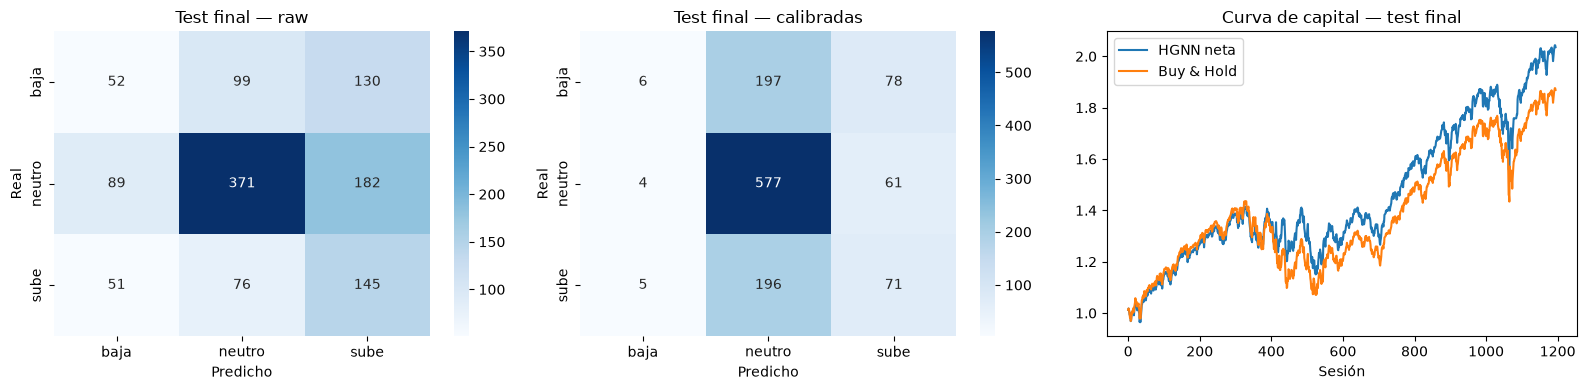

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (nombre, pred) in zip(axes[:2], [
    ('raw', probas_raw[mask_test].argmax(axis=1)),
    ('calibradas', probas_calibradas[mask_test].argmax(axis=1)),
]):
    cm = confusion_matrix(y_true[mask_test], pred, labels=[0, 1, 2])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['baja', 'neutro', 'sube'],
                yticklabels=['baja', 'neutro', 'sube'])
    ax.set_title(f'Test final — {nombre}')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

axes[2].plot(financiero_final.curva_estrategia, label='HGNN neta')
axes[2].plot(financiero_final.curva_buy_hold, label='Buy & Hold')
axes[2].set_title('Curva de capital — test final')
axes[2].set_xlabel('Sesión')
axes[2].legend()
plt.tight_layout()
plt.show()


## 11. Resumen automático y criterio de decisión


In [12]:
metricas_test_raw = metricas_probabilisticas(probas_raw[mask_test], y_true[mask_test])
metricas_test_cal = metricas_probabilisticas(probas_calibradas[mask_test], y_true[mask_test])
baseline_test = resumen_clasificacion(
    'majority por fold', y_true[mask_test], preds_majority[mask_test],
)

print('=== RESULTADO NB04 — SOLO TEST FINAL ===')
print(f'n fechas únicas: {mask_test.sum()}')
print(f'F1 macro baseline / HGNN calibrada: {baseline_test["f1_macro"]:.4f} / {metricas_test_cal["f1_macro"]:.4f}')
print(f'Balanced acc baseline / HGNN: {baseline_test["balanced_accuracy"]:.4f} / {balanced_accuracy_score(y_true[mask_test], probas_calibradas[mask_test].argmax(1)):.4f}')
print(f'NLL raw / calibrada: {metricas_test_raw["nll"]:.4f} / {metricas_test_cal["nll"]:.4f}')
print(f'Brier raw / calibrada: {metricas_test_raw["brier"]:.4f} / {metricas_test_cal["brier"]:.4f}')
print(f'ECE raw / calibrada: {metricas_test_raw["ece"]:.4f} / {metricas_test_cal["ece"]:.4f}')
print(f'Rentabilidad neta / BH: {financiero_final.rentabilidad_estrategia:+.2%} / {financiero_final.rentabilidad_buy_hold:+.2%}')
print(f'Sharpe neto: {financiero_final.sharpe_estrategia:.3f} | MaxDD: {financiero_final.max_drawdown_estrategia:.2%}')

mejora_clasificacion = metricas_test_cal['f1_macro'] > baseline_test['f1_macro']
mejora_calibracion = metricas_test_cal['nll'] < metricas_test_raw['nll']
print('\nDecisión:')
print('- Señal clasificatoria:', 'SÍ' if mejora_clasificacion else 'NO')
print('- Calibración mejora NLL:', 'SÍ' if mejora_calibracion else 'NO')
print('- Estrategia supera BH neto:', 'SÍ' if financiero_final.rentabilidad_vs_bh > 0 else 'NO')


=== RESULTADO NB04 — SOLO TEST FINAL ===
n fechas únicas: 1195
F1 macro baseline / HGNN calibrada: 0.2330 / 0.3503
Balanced acc baseline / HGNN: 0.3333 / 0.3937
NLL raw / calibrada: 1.0576 / 0.9695
Brier raw / calibrada: 0.6287 / 0.5723
ECE raw / calibrada: 0.0219 / 0.0484
Rentabilidad neta / BH: +103.56% / +86.90%
Sharpe neto: 0.982 | MaxDD: -18.90%

Decisión:
- Señal clasificatoria: SÍ
- Calibración mejora NLL: SÍ
- Estrategia supera BH neto: SÍ


### Lectura de resultados

- No se acepta una mejora por accuracy si no supera también el baseline por fold en macro-F1 o balanced accuracy.
- La calibración se considera útil si reduce NLL/Brier/ECE en el test final, no solo en el bloque donde se ajustó.
- La estrategia se juzga con rentabilidad y Sharpe netos, drawdown y número de cambios; no se extrapolan los resultados de las tres semillas como días adicionales.
- Si el HGNN combinado no supera los baselines, el siguiente experimento debe ser una ablación `market-only / GDELT-only / combinado` antes de ampliar la arquitectura.
